# Dual Pump Yoshi

The idea is that this notebook would replicate [this](https://opg.optica.org/abstract.cfm?URI=CLEO_SI-2021-SW4A.4) CLEO.

I wasn't able to get it to work though, I think I need to be able to add a second pump with independent detuning

In [1]:
from NLSE import CoupledRings
import numpy as np
import matplotlib.pyplot as plt

c = 299792458

wl_center = 1560e-9
omega_0 = 2 * np.pi * c / wl_center

neff = c / ( 699e-6 * 200e9 )

simulation = CoupledRings(
    neff=neff, 
    FSR_main=200e9,
    FSR_aux=206e9,
    coupling_ring_bus=0.001,
    coupling_ring_ring=0,
    coupling_ring_drop=0,
    gamma=1.229,
    alpha_int_main=8.643,
    alpha_int_aux=4.321,
    beta_2=20e-27,
    omega_0=omega_0
)

intensity_in = 0.3

# A_in = 1j * np.sqrt(intensity_in) * np.ones(simulation.time.shape)
A_in_freq = np.zeros(simulation.frequency.shape, dtype=complex)
# A_in_freq[0] = 1j * np.sqrt(intensity_in) * len(A_in_freq)

A_in_freq[3] = 1j * np.sqrt(intensity_in / 2) * len(A_in_freq)
A_in_freq[-3] = 1j * np.sqrt(intensity_in / 2) * len(A_in_freq)

A_in = np.fft.ifft(A_in_freq)
A_init = np.zeros(simulation.time.shape)

run_sim = simulation.get_ikeda_map()
A_main, A_aux, A_out, A_drop = run_sim(A_init, A_init, A_in, detuning_main=0.015, detuning_aux=0.1891, nrt=10000, n_per_step=5)

average_power = ( np.sum(np.abs(A_in) ** 2) * ( simulation.time[1] - simulation.time[0] ) ) / np.ptp(simulation.time)
print(f'{average_power=:.5f} W')

average_power=0.30059 W


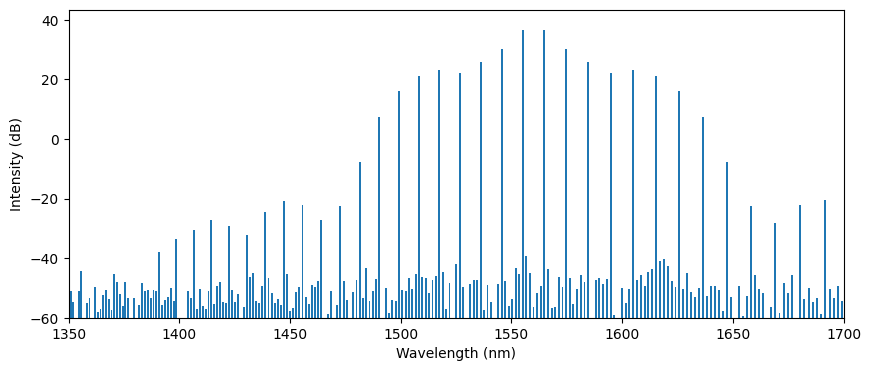

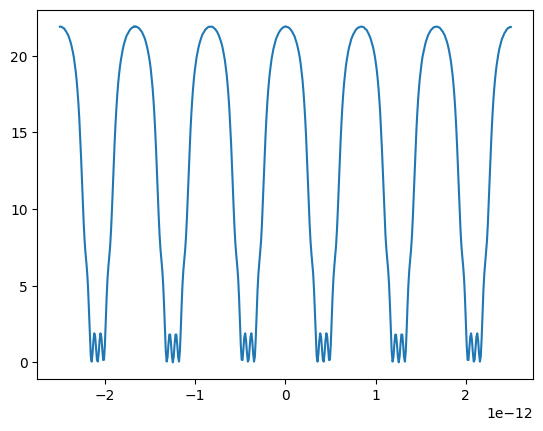

In [2]:
import matplotlib.pyplot as plt

dBm = lambda arr: 10 * np.log10( arr ) + 30

cross_section = np.abs( np.fft.fft(A_main[-1]) ) ** 2 / A_main[0].size ** 2

plt.figure(figsize=(10,4))
plt.bar(1e9 * simulation.wavelength, dBm(cross_section) + 100, width=0.5 * np.mean(np.diff(np.fft.fftshift(1e9 * simulation.wavelength))), bottom=-100, align='center')
plt.ylim(bottom=-60)
plt.xlim(1350, 1700)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (dB)')
plt.show()

plt.plot(simulation.time, np.abs(A_main[-1])**2)
plt.show()